# Make time series plots of flow and exports for the threee scenarios

In [7]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
# import datetime.datetime as datetime

In [8]:
# load the flux time series for each scenario
base=pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/time_history/flux.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
dcp=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/flux_s0065.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cor=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/flux_s0044.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
base

,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2006-10-01 00:00:00,-0.62,0.67,4.52,262.320007,120.830002,-94.860001,-0.0,-25.780001,-72.769997,-329.829987,0.690000,-0.00,2.48,-0.01,0.00
2006-10-01 00:15:00,-0.62,0.67,4.52,263.239990,120.820000,-94.860001,-0.0,-25.730000,-71.919998,-329.890015,-4.620000,-0.00,2.46,-0.01,0.00
2006-10-01 00:30:00,-0.62,0.66,4.52,263.410004,120.820000,-95.430000,-0.0,-25.690001,-73.339996,-330.239990,-8.100000,-0.00,2.46,-0.01,0.00
2006-10-01 00:45:00,-0.62,0.66,4.52,263.390015,120.820000,-94.860001,-0.0,-25.660000,-73.910004,-330.299988,-9.660000,-0.00,2.45,-0.01,0.00
2006-10-01 01:00:00,-0.62,0.66,4.52,263.350006,120.820000,-94.860001,-0.0,-25.629999,-73.910004,-330.649994,-10.650000,-0.00,2.45,-0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-14 23:00:00,-0.76,0.00,3.40,1.010000,98.879997,-79.940002,-0.0,-76.169998,-144.699997,-1716.310059,-113.269997,-9.06,0.54,-5.10,1.17
2026-01-14 23:15:00,-0.74,0.00,3.42,3.000000,98.870003,-79.919998,-0.0,-76.180000,-144.699997,-1716.869995,-113.269997,-8.50,0.55,-5.04,1.18
2026-01-14 23:30:00,-0.74,0.00,3.44,7.780000,98.860001,-79.900002,-0.0,-76.180000,-144.130005,-1716.869995,-113.269997,-8.50,0.57,-5.10,1.20


(np.float64(17805.0), np.float64(18169.0))

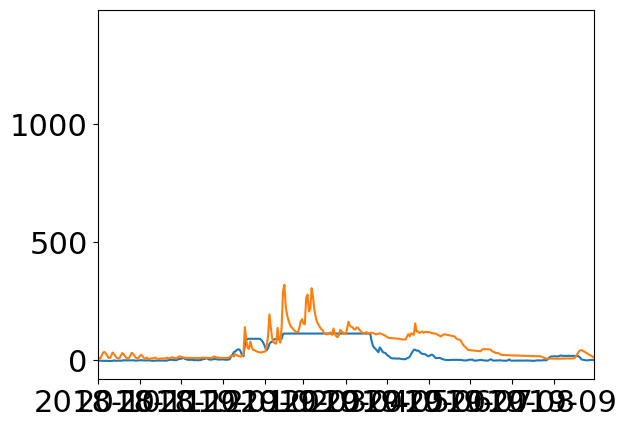

In [9]:
# load the time series of tunnel exports
dcp_sinks=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/vsink_DCP_dated_single.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
tunnel=dcp_sinks['dcp_sink_1']*-1
tunnel

datetime
1999-12-01    0.645749
1999-12-02    1.721087
1999-12-03    2.633532
1999-12-04    3.423981
1999-12-05    4.123873
                ...   
2023-09-26         NaN
2023-09-27         NaN
2023-09-28         NaN
2023-09-29         NaN
2023-09-30         NaN
Name: dcp_sink_1, Length: 8705, dtype: float32

In [10]:
# resample to be daily
base=base.resample('D').mean()
dcp=dcp.resample('D').mean()
cor=cor.resample('D').mean()
dcp

,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2017-01-01,-0.212677,2.234565,-0.068326,251.409668,125.984367,-147.251907,-36.339794,-213.941467,-391.635834,-1674.256348,-18.147291,-0.001,2.856915,-3.286729,2.514083
2017-01-02,-0.265302,2.463265,-0.078510,270.016022,128.255539,-166.778885,-42.105236,-237.906616,-412.593140,-1764.791992,-8.187917,-0.001,3.003441,-3.141646,2.393594
2017-01-03,-0.444490,2.653118,-0.086627,277.585693,129.179642,-183.275375,-46.915501,-257.875153,-430.150024,-1839.955688,-12.855000,-0.001,3.125143,-9.149854,1.657260
2017-01-04,-1.348437,2.812090,-0.093015,281.401581,129.645645,-197.436829,-50.972683,-274.685608,-445.044922,-1902.901245,-12.929375,-0.001,3.227139,-115.532745,1.464136
2017-01-05,-2.720062,2.946205,-0.097919,283.589691,129.913055,-209.797470,-54.430248,-288.974152,-457.840698,-1956.011841,-21.772812,-0.001,3.313278,-35.627293,1.839313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-28,-9.078750,1.784479,0.025760,23.961042,48.238834,-57.580601,0.000000,-71.976494,-56.691357,-902.439026,-47.315414,-0.001,0.396094,-20.489292,0.444010
2021-12-29,-8.497760,1.570448,0.001240,0.171250,73.468071,-68.461876,0.000000,-55.672321,-55.465679,-812.193542,-49.463123,-0.001,0.396458,-19.107374,0.014375
2021-12-30,-10.388750,1.798344,0.000042,23.828230,73.369484,-70.243462,0.000000,-46.136600,-111.594933,-714.609192,-47.992813,-0.001,0.424844,-15.624428,0.000677


In [11]:
# calculate total inflows and exports
base['exports']=base.swp+base.cvp+base.ccc_rock+base.northbay+base.ccc_victoria
dcp['exports']=dcp.swp+dcp.cvp+dcp.ccc_rock+dcp.northbay+dcp.ccc_victoria+tunnel
cor['exports']=cor.swp+cor.cvp+cor.ccc_rock+cor.northbay+cor.ccc_victoria

base['inf']=(base['sac']+base['east']+base['sjr']+base['yolo']+base['calaveras']+base['yolo_toedrain']+base['coyote']+base['napa']+base['american'])*-1
dcp['inf']=(dcp['sac']+dcp['east']+dcp['sjr']+dcp['yolo']+dcp['calaveras']+dcp['yolo_toedrain']+dcp['coyote']+dcp['napa']+dcp['american'])*-1
cor['inf']=(cor['sac']+cor['east']+cor['sjr']+cor['yolo']+cor['calaveras']+cor['yolo_toedrain']+cor['coyote']+cor['napa']+cor['american'])*-1

base['net']=base.inf-base.exports
dcp['net']=dcp.inf-dcp.exports
cor['net']=cor.inf-cor.exports

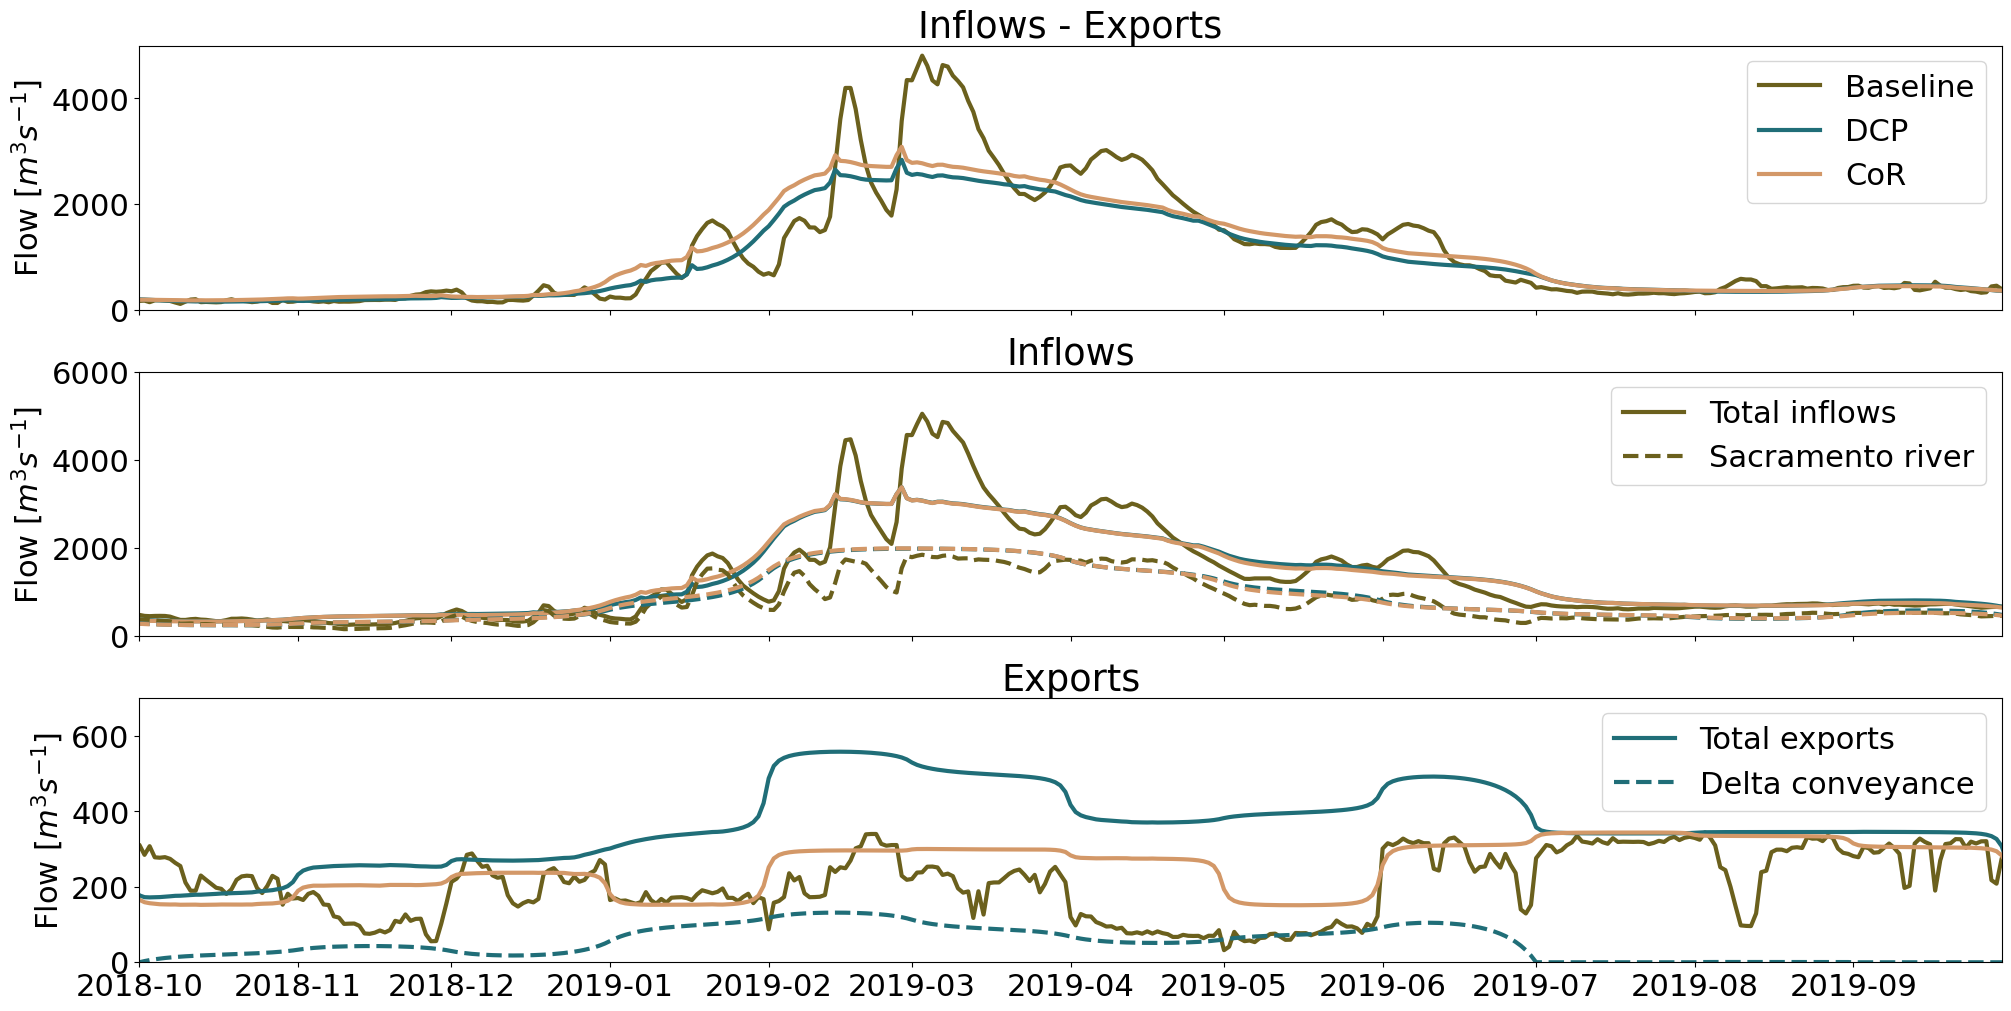

In [41]:
# make stacked plots 
fig, ax = plt.subplots(3,figsize=(20,10),sharex=True,layout='constrained')
mpl.rcParams.update({'font.size': 22})

ax[0].plot(base.net,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
ax[0].plot(dcp.net,label='DCP', linewidth=3,color=cmocean.cm.tarn(10/12))
ax[0].plot(cor.net,label='CoR', linewidth=3,color=cmocean.cm.tarn(2/6))
ax[0].set_title('Inflows - Exports')
ax[0].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,5000)
ax[0].legend()

ax[1].plot(base.inf, linewidth=3,label='Total inflows',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.inf, linewidth=3,color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.inf, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[1].plot(base.sac*-1, linewidth=3,label='Sacramento river',color=cmocean.cm.tarn(1/6),linestyle='--')
ax[1].plot(dcp.sac*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--')
ax[1].plot(cor.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[1].plot(base.sjr*-1, linewidth=3,label='San Joaquin river',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.sjr*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# ax[1].plot(cor.sjr*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].plot(base.yolo*-1, linewidth=3,label='Yolo bypass',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.yolo*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# # ax[1].plot(cor.yolo*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

ax[1].legend()
ax[1].set_title('Inflows')
ax[1].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[1].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[1].set_ylim(0,6000)

ax[2].plot(base.exports, linewidth=3,color=cmocean.cm.tarn(1/6))
ax[2].plot(dcp.exports, linewidth=3,color=cmocean.cm.tarn(10/12),label='Total exports')
ax[2].plot(cor.exports, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[2].plot(tunnel, linewidth=3,linestyle='--',label='Delta conveyance',color=cmocean.cm.tarn(10/12))

ax[2].legend()
ax[2].set_title('Exports')
ax[2].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[2].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[2].set_ylim(0,700)

fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/inflows_exports_scenarios.png')

In [30]:
import matplotlib.dates as mdates

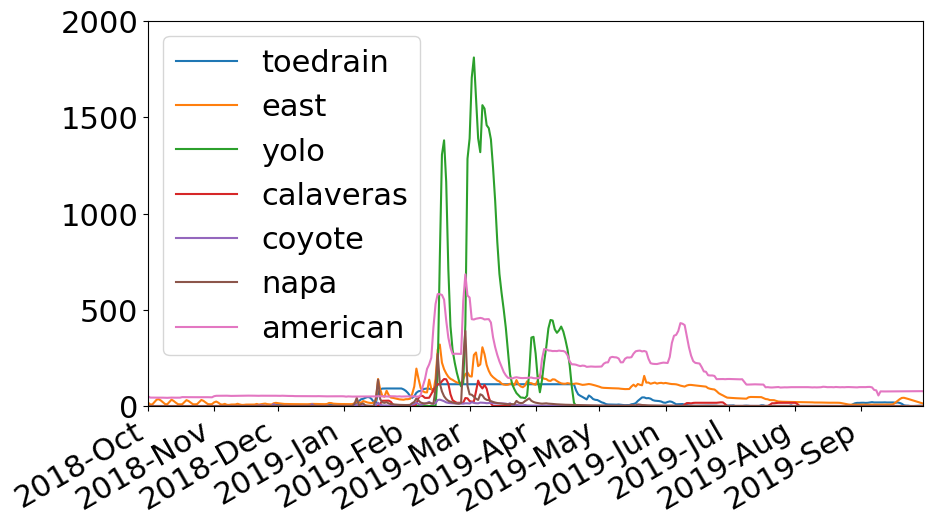

In [31]:
# what is the rest of the peak inflows for the basecase
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(base.yolo_toedrain*-1,label='toedrain')
ax.plot(base.east*-1,label='east')
ax.plot(base['yolo']*-1,label='yolo')
ax.plot(base['calaveras']*-1,label='calaveras')
ax.plot(base['coyote']*-1,label='coyote')
ax.plot(base['napa']*-1,label='napa')
ax.plot(base['american']*-1,label='american')
ax.set_ylim(0,2000)
ax.legend()
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))

ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

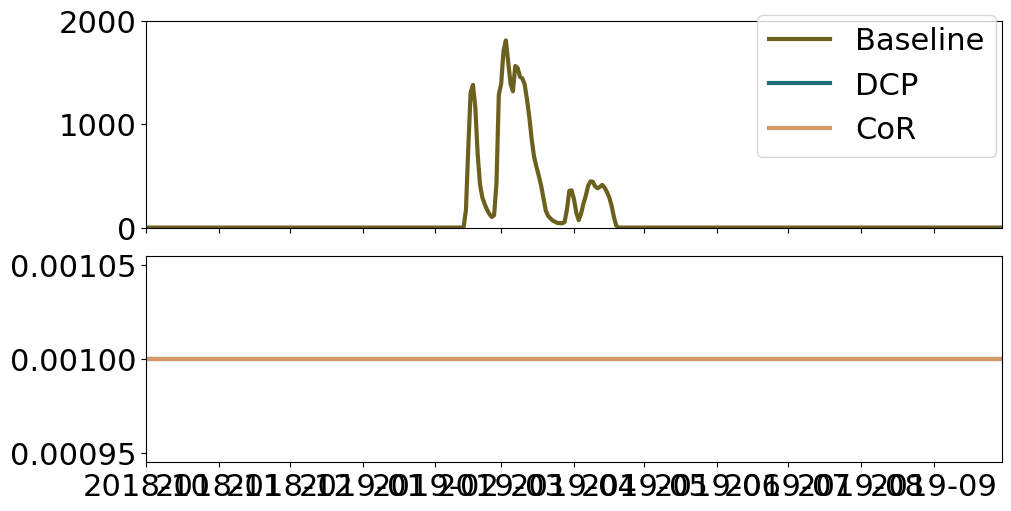

In [37]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.yolo*-1, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.yolo*-1, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.yolo*-1, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,2000)
fig.legend()

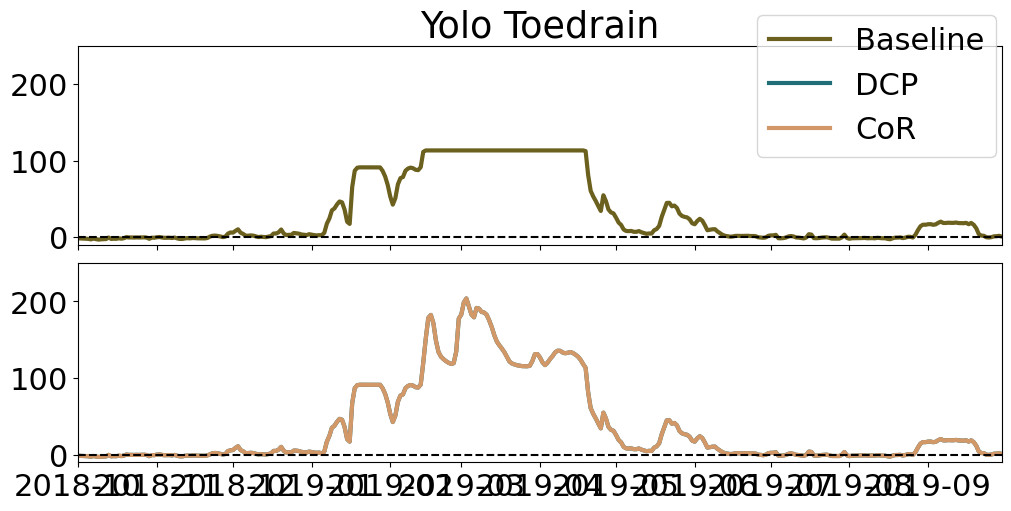

In [48]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.yolo_toedrain*-1, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.yolo_toedrain*-1, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.yolo_toedrain*-1, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,250)
ax[1].set_ylim(-10,250)
ax[0].set_title('Yolo Toedrain')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()

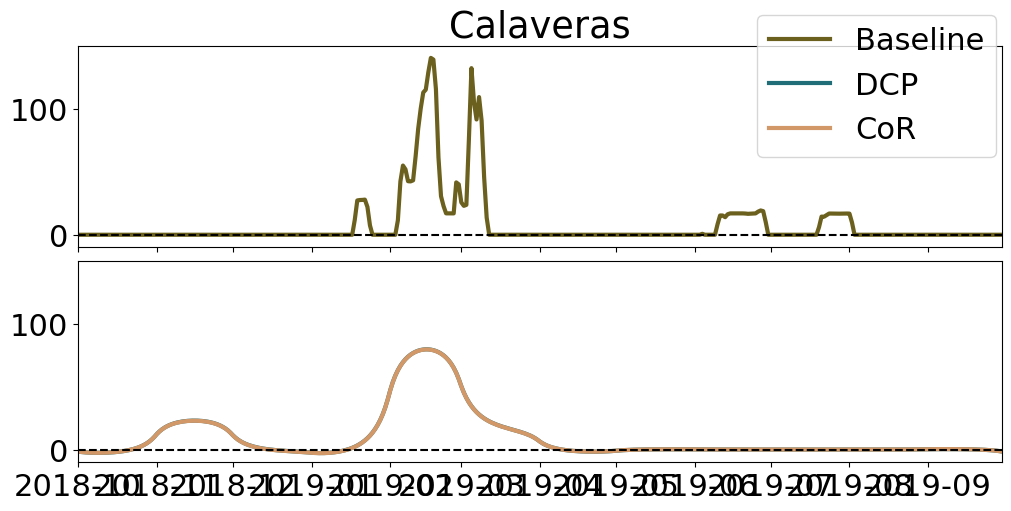

In [50]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.calaveras*-1, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.calaveras*-1, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.calaveras*-1, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,150)
ax[1].set_ylim(-10,150)
ax[0].set_title('Calaveras')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()

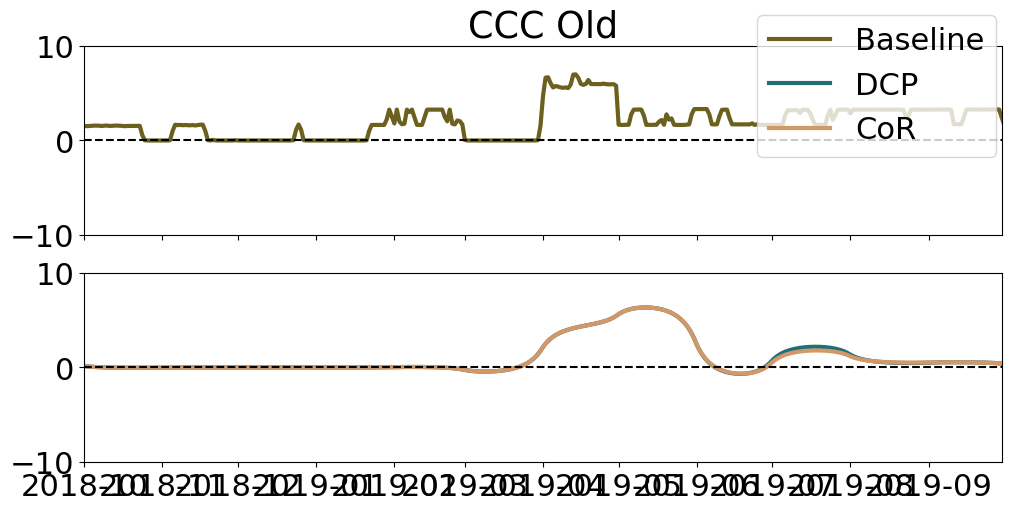

In [53]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.ccc_old, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.ccc_old, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.ccc_old, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,10)
ax[1].set_ylim(-10,10)
ax[0].set_title('CCC Old')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()

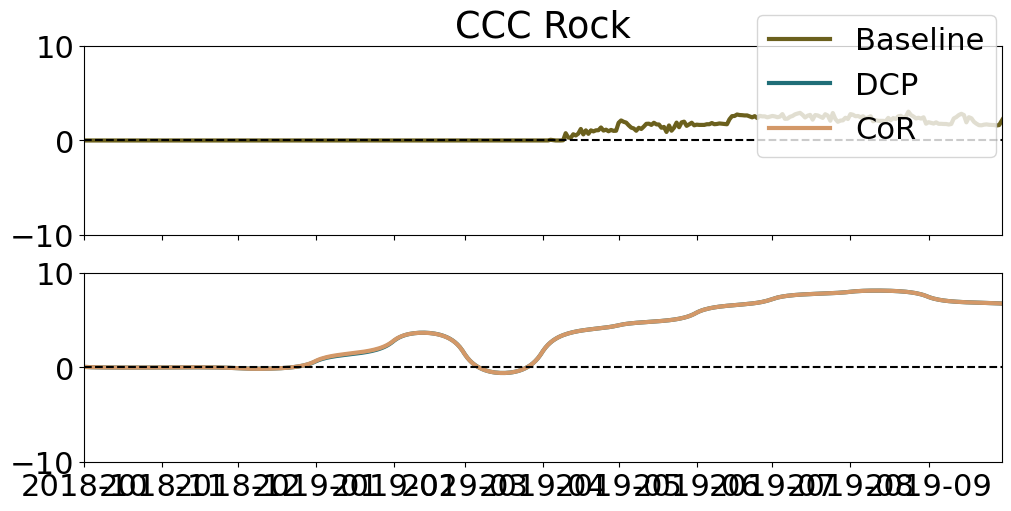

In [54]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.ccc_rock, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.ccc_rock, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.ccc_rock, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,10)
ax[1].set_ylim(-10,10)
ax[0].set_title('CCC Rock')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()